# Deep-dive into trained models

Recall the high-level structure of NeuralGCM models, from Figure 1 of the 
NeuralGCM paper:

![](./_static/neuralgcm-flowchart.png)

In code, trained models are encapsulated in a
{py:class}`neuralgcm.PressureLevelModel` object, in particular the 
{py:meth}`~neuralgcm.PressureLevelModel.encode`,
{py:meth}`~neuralgcm.PressureLevelModel.decode`
and {py:meth}`~neuralgcm.PressureLevelModel.advance` methods, which
correspond to learned transformations.

训练后模型深入解析

回顾 NeuralGCM 论文图 1 中展示的 NeuralGCM 模型高层结构：

在代码中，训练后模型被封装在 
{py:class}neuralgcm.PressureLevelModel对象中。其中尤为关键的是 
{py:meth}~neuralgcm.PressureLevelModel.encode、
{py:meth}~neuralgcm.PressureLevelModel.decode和 
{py:meth}~neuralgcm.PressureLevelModel.advance方法，这些方法对应于习得的变换。


## Loading a model

Pre-trained NeuralGCM models can be loaded from checkpoint files saved to disk with the {py:meth}`~neuralgcm.PressureLevelModel.from_checkpoint` constructor, as shown in the {doc}`./inference_demo`. Here we'll use the very small (toy) model distributed as part of the `neuralgcm` Python package:

预训练 NeuralGCM 模型可通过 {py:meth}~neuralgcm.PressureLevelModel.from_checkpoint 构造函数，从保存到磁盘的检查点文件中加载，具体示例见 {doc}./推理演示。本文将使用 neuralgcm Python 包中自带的超小型（玩具级）模型：

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5,6'
device_ids = [0, 1]

import jax
import matplotlib.pyplot as plt
import numpy as np
import neuralgcm
import pprint
import xarray

checkpoint = neuralgcm.demo.load_checkpoint_tl63_stochastic()
model = neuralgcm.PressureLevelModel.from_checkpoint(checkpoint)
# JAX0.4.6 JAXLIB0.4.6 No module named 'jax.extend'
# JAX0.4.12 JAXLIB0.4.12 该代码单元报错 cannot import name 'linear_util' from 'jax.extend' (/home/zhangjing/anaconda3/envs/JAX/lib/python3.10/site-packages/jax/extend/__init__.py) # jax.linear_util 在 JAX v0.4.16 中已被 弃用，并且 在 JAX v0.4.24 中被删除。
# JAX0.4.13 JAXLIB0.4.13 该代码单元报错 cannot import name 'linear_util' from 'jax.extend' (/home/zhangjing/anaconda3/envs/JAX/lib/python3.10/site-packages/jax/extend/__init__.py)
# JAX0.4.14 JAXLIB0.4.14 该代码单元报错 cannot import name 'linear_util' from 'jax.extend' (/home/zhangjing/anaconda3/envs/JAX/lib/python3.10/site-packages/jax/extend/__init__.py)， 再安装pip install flax==0.5.3解决,但再次出现module 'jax' has no attribute 'tree'
# JAX0.4.16 JAXLIB0.4.16 该代码单元报错 module 'jax.typing' has no attribute 'DTypeLike'
# JAX0.4.17 JAXLIB0.4.17 可通过该代码单元，但后边会module 'jax' has no attribute 'tree'
# JAX0.4.18 JAXLIB0.4.18 可通过该代码单元，但后边会module 'jax' has no attribute 'tree'
# JAX0.4.20 JAXLIB0.4.20 可通过该代码单元，但后边会module 'jax' has no attribute 'tree'
# JAX0.4.22 JAXLIB0.4.22 可通过该代码单元，但后边会module 'jax' has no attribute 'tree'
# JAX0.4.23 JAXLIB0.4.23 可通过该代码单元，但后边会module 'jax' has no attribute 'tree'  !pip install "jax<=0.3.16" "jaxlib<=0.3.16"
# JAX0.4.24 JAXLIB0.4.24 该代码单元报错 module 'jax.random' has no attribute 'KeyArray' 搜到jax.random.KeyArray 在 JAX v0.4.16 被弃用 且在 JAX v0.4.24.被删除 # jax.linear_util 在 JAX v0.4.16 中已被 弃用，并且 在 JAX v0.4.24 中被删除。
# JAX0.4.25 JAXLIB0.4.25 该代码单元报错 module 'jax.random' has no attribute 'KeyArray', 
# JAX0.4.30 JAXLIB0.4.30 该代码单元报错 jax.core.Shape 已经被弃用，并建议使用 Shape = Sequence[int | Any] 作为替代
# JAX0.4.35 JAXLIB0.4.35 该代码单元报错 jax.core.Shape 已经被弃用，并建议使用 Shape = Sequence[int | Any] 作为替代



#
# jax.tree_multimap was deprecated in JAX version 0.3.5, and removed in JAX version 0.3.16.
# You can either change the source to use jax.tree_map as a drop-in replacement for jax.tree_multimap, or install an older version of JAX, e.g.:

{doc}`./datasets` describes how to prepare data in detail. Here we'll load testing data already downsampled to the required resolution:

{doc}./datasets 详细介绍了数据准备的方法。本文将加载已下采样至所需分辨率的测试数据：

In [2]:
ds = neuralgcm.demo.load_data(model.data_coords)
ds_init = ds.isel(time=0)
inputs, forcings = model.data_from_xarray(ds_init)

2025-11-13 16:23:47.962055: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Encoding & decoding data

{py:meth}`~neuralgcm.PressureLevelModel.encode` transforms input data (on pressure levels) into model variables (on sigma levels). To use it, pass in dictionaries of input and forcing data and, for stochastic models, a JAX [RNG key](https://jax.readthedocs.io/en/latest/jax.random.html) used to sample random noise:

{py:meth}~neuralgcm.PressureLevelModel.encode 会将输入数据（位于气压层）转换为模型变量（位于 σ 层）。使用该方法时，需传入输入数据和驱动数据的字典；对于随机模型，还需传入用于采样随机噪声的 JAX 随机数生成键：

In [3]:
encoded = model.encode(inputs, forcings, jax.random.key(0))
# jax-0.4.35 jaxlib-0.4.35 ml-dtypes-0.5.0 optax-0.2.0, 版本太新，提示参数问题

{py:meth}`~neuralgcm.PressureLevelModel.decode` can be used to convert back from model levels to pressure levels:

{py:meth}~neuralgcm.PressureLevelModel.decode 可用于将模型层转换回气压层：

In [4]:
decoded = model.decode(encoded, forcings)

Encoding/decoding is a lossy process, because NeuralGCM's encoded model state uses a different coordinate system. For this model, it introduces about 1 degree of error on average near the surface:

编码 / 解码是一个有损过程，因为 NeuralGCM 的编码后模型状态采用了不同的坐标系。对于该模型，这会在近地表附近引入平均约 1 度的误差：

In [5]:
abs(inputs['temperature'][-1] - decoded['temperature'][-1]).mean()

Array(1.2626412, dtype=float32)

## Advancing in time
时间推进

{py:meth}`~neuralgcm.PressureLevelModel.advance` and {py:meth}`~neuralgcm.PressureLevelModel.unroll` allow for stepping encoded model state forward in time, using a combination of NeuralGCM dycore and learned physics.

{py:meth}~neuralgcm.PressureLevelModel.advance 和 {py:meth}~neuralgcm.PressureLevelModel.unroll 可结合 NeuralGCM 动力核心与习得物理过程，实现编码后模型状态的时间步推进。

`advance` steps forward a single time-step in time, of size `model.timestep` (typically 30 or 60 minutes):

advance 方法会推进一个时间步长，其时长为 model.timestep（通常为 30 或 60 分钟）：

In [6]:
assert model.timestep == np.timedelta64(1, 'h')
advanced = model.advance(encoded, forcings)

{py:meth}`~neuralgcm.PressureLevelModel.unroll` is the higher-level method for stepping forward multiple steps at once, with post-processing outputs at a given time interval:

{py:meth}~neuralgcm.PressureLevelModel.unroll 是更高级别的方法，可一次推进多个时间步，并在给定时间间隔输出后处理结果：

In [7]:
all_forcings = model.forcings_from_xarray(ds)
advanced, outputs = model.unroll(encoded, all_forcings, steps=4, timedelta=np.timedelta64(1, 'h'))
# JAX==0.4.20,JAXLIB==0.4.20,ml_dtypes==0.2.0,scipy==1.12.0

Unlike forcings on `encoded`, `decode` and `advance`, the forcings argument to `unroll` should include a leading dimension. At each model time-step, the nearest forcing data in time is used to advance in time, which allows for controlling how forcings get updated over the course of a long time integration:

- For persistence forcings (i.e., to keep sea surface temperature and sea ice concentration constant over the forecast period), simply supply a dataset with a `time` dimension of size 1, corresponding to the initial conditions.
- For dynamic forcings, pass in a dataset to {py:meth}`~neuralgcm.PressureLevelModel.forcings_from_xarray` that changes over time at the desired time granularity. ERA5's sea surface temperature and sea ice concentration variables exclude the diurnal cycle and are updated only about once daily, so passing in hourly forcings is unnecessary.

与 encoded、decode 和 advance 方法的驱动数据不同，unroll 方法的驱动数据参数需包含一个首维。在每个模型时间步，会使用时间上最接近的驱动数据进行时间推进，这使得在长时间积分过程中，能够控制驱动数据的更新方式：

对于持久驱动数据（即在预报期间保持海表温度和海冰浓度不变），只需提供一个时间维度大小为 1 的数据集，对应初始条件即可。

对于动态驱动数据，需将随时间变化的数据集按所需时间粒度传入 {py:meth}~neuralgcm.PressureLevelModel.forcings_from_xarray 方法。ERA5 的海表温度和海冰浓度变量不含日变化周期，且更新频率约为每日一次，因此无需传入逐小时驱动数据。

The `advanced` state is the updated encoded state after taking all of the indicated time-steps (4 hours in this case), which could be fed back into `unroll` advance further in time. This allows for making very long time integrations without running out of memory, e.g., something like:

“推进后的状态（advanced state）” 是完成所有指定时间步（本例中为 4 小时）后更新的编码后状态，可反馈至 unroll 方法进一步推进时间。这使得无需担心内存耗尽即可进行极长时间的积分运算，例如：

```python
t0 = np.datetime64(...)
inputs, forcings = model.data_from_xarray(ds.sel(time=t0))
state = model.encode(inputs, forcings, jax.random.key(0))

dt = np.timedelta(24, 'h')  # save outputs once per day
weeks = 52  # forecast one year in total
steps = 7  # forecast one week at a time

for w in range(weeks):
    t = t0 + w * steps * dt
    forcings = model.forcings_from_xarray(ds.sel(time=t))  # update forcings
    state, outputs = model.unroll(state, forcings, steps=steps, timedelta=dt)
    # save outputs to disk
```


```{note}
There is currently no public API for separating tendencies from dynamics and learned physics.
```

## JAX transformations (jit, grad, etc)

{py:class}`neuralgcm.PressureLevelModel` objects are [JAX pytrees](https://jax.readthedocs.io/en/latest/pytrees.html), where the leaves are the learnable neural network parameters.

This means you can compose NeuralGCM models with all of JAX's powerful transformations such `jit`, `grad` and `vmap`. Here's a simple example of fine-tuning our toy model with [Optax](https://optax.readthedocs.io/) to reduce reconstruction error:

JAX 变换（jit、grad 等）

{py:class}neuralgcm.PressureLevelModel 对象是 JAX PyTree 数据结构，其叶子节点为可学习神经网络参数。

这意味着你可以将 NeuralGCM 模型与 JAX 所有强大的变换（如jit、grad和vmap）结合使用。以下是一个简单示例：使用 Optax 微调玩具模型，以降低重建误差：

In [8]:
import jax
import optax

@jax.jit
def compute_loss(model, inputs, forcings, rng):
    encoded = model.encode(inputs, forcings, rng_key=rng)
    restored = model.decode(encoded, forcings)
    return abs(inputs['temperature'] - restored['temperature']).mean()

In [9]:
compute_loss(model, inputs, forcings, jax.random.key(0))

Array(6.224214, dtype=float32)

In [10]:
optimizer = optax.adam(1e-3)
opt_model = model
opt_state = optimizer.init(model)
for i in range(5):
    loss, grads = jax.value_and_grad(compute_loss)(
        opt_model, inputs, forcings, jax.random.key(0)
    )
    updates, opt_state = optimizer.update(grads, opt_state)
    opt_model = optax.apply_updates(opt_model, updates)
    print(f'{i=}, {loss=}')

i=0, loss=Array(6.2244086, dtype=float32)
i=1, loss=Array(4.6727533, dtype=float32)
i=2, loss=Array(3.8581243, dtype=float32)
i=3, loss=Array(3.5509636, dtype=float32)
i=4, loss=Array(3.4368043, dtype=float32)


## Encoded model state

```{warning}
There are no stable API guarantees for encoded model state, beyond the data being guaranteed to be a [JAX pytree](https://jax.readthedocs.io/en/latest/pytrees.html). Expect different models (especially in future versions of NeuralGCM) to store state in different ways.
```

Model state is big, so we'll only look at shapes:

In [11]:
pprint.pprint(jax.tree.map(np.shape, encoded))

ModelState(state=StateWithTime(vorticity=(32, 128, 65),
                               divergence=(32, 128, 65),
                               temperature_variation=(32, 128, 65),
                               log_surface_pressure=(1, 128, 65),
                               sim_time=(),
                               tracers={'specific_cloud_ice_water_content': (32,
                                                                             128,
                                                                             65),
                                        'specific_cloud_liquid_water_content': (32,
                                                                                128,
                                                                                65),
                                        'specific_humidity': (32, 128, 65)}),
           memory=None,
           diagnostics={},
           randomness=RandomnessState(core=(10, 128, 65),
                       

Internally, model state is represented using a different set of variables (vorticity, divergence, temperature variation and log surface pressure) more appropriate to NeuralGCM's spectral dynamical core. Each variable is stored vertically on sigma levels and horizontally as spherical harmonic coefficients, and using Dinosaur's internal non-dimensional units rather than SI units.

We can convert back using utility methods from Dinosaur and NeuralGCM:

在内部，模型状态通过另一组变量（涡度、散度、温度变率和地表气压的对数）来表示，这组变量更适合 NeuralGCM 的谱动力核心。每个变量在垂直方向上存储于 σ 层，在水平方向上以球谐系数形式存储，并且使用 Dinosaur 内部的无量纲单位而非国际单位制单位。
我们可以使用 Dinosaur 和 NeuralGCM 的工具方法进行反向转换：

In [12]:
from dinosaur import spherical_harmonic

nodal_vorticity = model.model_coords.horizontal.to_nodal(encoded.state.vorticity)
nodal_divergence = model.model_coords.horizontal.to_nodal(encoded.state.divergence)

nodal_u_wind, nodal_v_wind = spherical_harmonic.vor_div_to_uv_nodal(
    model.model_coords.horizontal,
    encoded.state.vorticity,
    encoded.state.divergence,
)

encoded_ds = model.data_to_xarray(
    {
        'vorticity': model.from_nondim_units(nodal_vorticity, '1/s'),
        'divergence': model.from_nondim_units(nodal_divergence, '1/s'),
        'u_wind': model.from_nondim_units(nodal_u_wind, 'm/s'),
        'v_wind': model.from_nondim_units(nodal_v_wind, 'm/s'),
    },
    times=None,
    decoded=False,
)

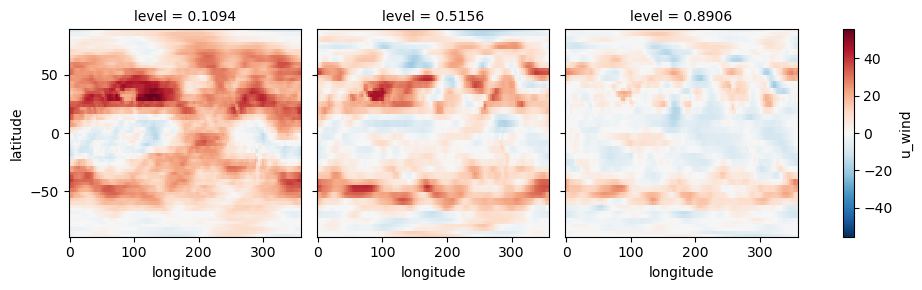

In [13]:
encoded_ds.u_wind.sel(level=[0.1, 0.5, 0.9], method='nearest').plot.imshow(
    x='longitude', y='latitude', col='level',
);

You can also work with state in the spherical harmonic (modal) representation, which is sometimes convenient, e.g., for calculating power spectra. Here care should be taken to ensure that structural sparsity is handled properly, because many of the entries in these arrays are always fixed at zero:

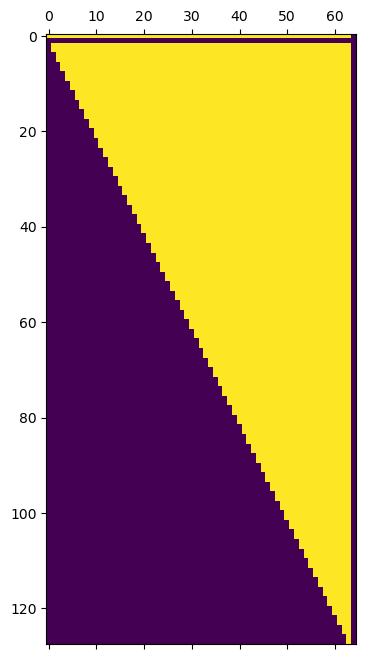

In [14]:
plt.matshow(encoded.state.temperature_variation[0] != 0);

The non-zero mask can be accessed programmatically:

In [15]:
model.model_coords.horizontal.mask

array([[ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [False,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ..., False,  True,  True],
       [False, False, False, ..., False,  True,  True]])

For more details, see the [source code](https://github.com/google-research/dinosaur/blob/main/dinosaur/spherical_harmonic.py) for spherical harmonics in Dinosaur.

## Random noise

NeuralGCM stochastic models use JAX's [deterministic and explicit random number generation](https://jax.readthedocs.io/en/latest/jax.random.html).

You can control noise via the `rng_key` argument in {py:meth}`~neuralgcm.PressureLevelModel.encode`, which is optional for deterministic models. To make multiple stochastic forecasts (as many as desired), simply pass in different RNG keys, e.g.,

In [16]:
encoded = model.encode(inputs, forcings, jax.random.key(0))
encoded2 = model.encode(inputs, forcings, jax.random.key(1))

In [17]:
# slightly different average temperatures
encoded.state.temperature_variation.mean(), encoded2.state.temperature_variation.mean()

(Array(-0.0040093, dtype=float32), Array(-0.00391526, dtype=float32))

Randomness in the learned physics is also controlled via the same `rng_key` argument, which initializes an RNG key on the model state. You can visualize the Gaussian random fields:

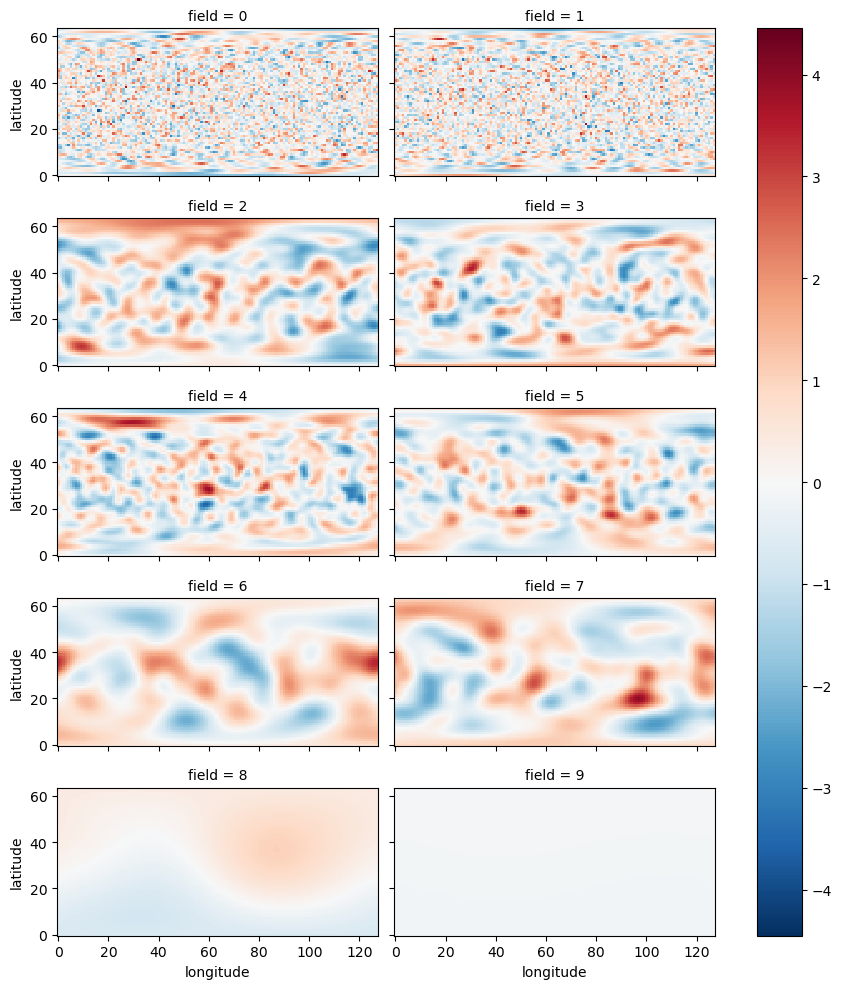

In [18]:
xarray.DataArray(
    encoded.randomness.nodal_value,
    dims=['field', 'longitude', 'latitude'],
).plot(x='longitude', y='latitude', col='field', col_wrap=2, aspect=2, size=2);

Adjusting random noise on an existing model state is also possible (on current stochastic NeuralGCM models) by replacing  `encoded.randomness.rng_key`, e.g., 

In [19]:
encoded_with_new_rng = encoded.replace(randomness=encoded.randomness.replace(prng_key=jax.random.key(123)))

These fields will slowly diverge after advancing in time due to new noise being injected at each time step:

In [20]:
advanced_with_new_rng = model.advance(encoded_with_new_rng, forcings)

In [21]:
advanced.state.temperature_variation.mean(), advanced_with_new_rng.state.temperature_variation.mean()

(Array(-0.00416604, dtype=float32), Array(-0.00419673, dtype=float32))